In [1]:
import plotly.express as px
import pandas as pd
from scipy import stats
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from collections import Counter


In [3]:
query = '''
SELECT *
FROM read_parquet('parquet_data/players.parquet')
'''

fig = px.histogram(duckdb.query(query).to_df(), x= 'league_points', nbins= 40,
                   marginal= 'box')

fig.update_layout(title= "Распределение игроков по очкам лиги (LP)", 
                  xaxis_title= "Очки лиги",
                  yaxis_title= "Количество",
                  template="plotly_white")

fig.show()

В большинстве соревновательных игр распределение игроков по рейтингу (LP, MMR, ELO) не является симметричным. Обычно наблюдается положительная асимметрия (правый «хвост» длиннее):
- Основная масса игроков сосредоточена в диапазоне низких и средних LP (например, 0–1500).
- Пик («мода») часто смещён влево – в районе начальных значений LP (500–1000).
- С ростом LP количество игроков резко падает: чем выше ранг, тем меньше игроков.

In [ ]:
query = '''
SELECT champion,
       SUM(CASE WHEN win THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS win_rate
FROM read_parquet('parquet_data/matches.parquet')
GROUP BY champion
ORDER BY win_rate desc
LIMIT 15
'''

fig = px.bar(duckdb.query(query).to_df(), x= 'champion', y= 'win_rate')

fig.update_layout(title= "Топ-15 чемпионов по винрейту",
                  xaxis_title= "Чемпионы",
                  yaxis_title= "Винрейт_%",
                  template="plotly_white")
fig.show()

- В сбалансированной игре средний винрейт чемпиона стремится к 50%.
- Топ‑15 по винрейту обычно показывает значения от 51–52% (нижняя граница топа) до 54–58% (лидеры).
- Если ось доходит до 70% — это аномально высокий показатель. Реальный винрейт редко превышает 60% даже у самых сильных чемпионов (исключение — ошибки баланса или очень низкая частота выборов).

Значения выше 60% сигнализируют о дисбалансе (чемпион слишком силён) или о том, что статистика собрана на узком срезе (например, только мастера+).

In [ ]:
query = '''
SELECT champion, count(*) as count
FROM read_parquet('parquet_data/matches.parquet')
GROUP BY champion
ORDER BY count desc
LIMIT 15
'''

fig = px.bar(duckdb.query(query).to_df(), x= 'champion', y= 'count')

fig.update_layout(title= "Топ-15 чемпионов по популярности", 
                  xaxis_title= "Чемпионы",
                  yaxis_title= "Количестно",
                  template="plotly_white")
fig.show()

Ни один из популярных чемпионов не попал в топ‑15 по винрейту.
Это значит, что:
- Игроки чаще выбирают не самых сильных (по винрейту), а знакомых, комфортных, стабильных или модных персонажей.
- Чемпионы с высоким винрейтом имеют низкую популярность – вероятно, они ситуативны или сложны для большинства игроков.
- Высокая популярность Сенны, Нами, Эзреаля при «среднем» винрейте около 50% говорит о хорошей балансной зоне.



In [ ]:
query = '''
SELECT kills,
       deaths,
       assists,
       gold_earned,
       damage_to_champions,
       minions_killed,
       vision_score,
       game_duration_sec,
       CASE WHEN win THEN 1 ELSE 0 END as win_num
from read_parquet('parquet_data/matches.parquet')
'''

In [ ]:
fig = px.imshow(
    duckdb.query(query).to_df().corr(method='pearson')[['win_num']],
    text_auto='.2f',          # показываем значения с двумя знаками
    color_continuous_scale='RdBu_r',
    range_color=[-1, 1],
    aspect='auto',
    title='Корреляция признаков с исходом',
    labels=dict(x='Целевая переменная', y='Признаки', color='Корреляция')
)

fig.update_layout(
    template='plotly_white'
)
fig.show()

Смерти – самый важный негативный фактор. Коэффициент -0.37 означает, что увеличение количества смертей заметно снижает шансы на победу. Это сильнее, чем положительный вклад убийств (+0.26).

Участие в убийствах (assists + kills) важно. Assists даже чуть полезнее kills. Это говорит о командном характере игры – помогать добивать врагов не менее ценно, чем забирать фраги самому.

Экономика и урон имеют значение, но не решающие. Золото (0.21) и урон по чемпионам (0.13) полезны, но их вклад ниже, чем у assists и deaths.

Фарм, вижн и длительность игры почти не коррелируют с победой в рамках данной выборки.
Возможные причины:
- данные взяты из среднего/низкого ранга, где игроки плохо используют вижн и фармят неоптимально;
- фарм и вижн сильно коррелируют с другими признаками (например, с золотом), и их уникальный вклад мал;
- длительность игры не определяет исход – побеждать можно как быстро, так и долго.

In [ ]:
query = '''
SELECT         avg(kills) as avg_kills,
               avg(deaths) as avg_deaths,
               avg(assists) as avg_assists,
      CASE LEFT(match_id, 2 )
          WHEN 'NA' THEN 'americas'
          WHEN 'EU' THEN 'europe'
          WHEN 'RU' THEN 'europe'
      END AS region              
FROM read_parquet('parquet_data/matches.parquet')
GROUP BY region
'''

df_kda = duckdb.query(query).to_df().melt(id_vars=['region'], 
                                        value_vars=['avg_kills', 'avg_deaths', 'avg_assists'],
                                        var_name='metric', 
                                        value_name='value')

fig = px.bar(df_kda, 
             x='metric', 
             y='value', 
             color='region', 
             barmode='group',
             text_auto='.3f',  # показывает значения на столбцах
             title='Сравнение метрик между регионами (Americas vs Europe)',
             labels={'value': 'Среднее значение', 'metric': 'Метрика', 'region': 'Регион'},
             color_discrete_map={'americas': 'steelblue', 'europe': 'darkorange'})

fig.update_layout(
    yaxis_title='Среднее значение',
    xaxis_title='Метрика',
    legend_title='Регион'
)

fig.show()

Kills (фраги)
Europe опережает Americas. Разница небольшая, оба региона показывают близкую эффективность в убийстве противников.
- Возможная причина: стиль игры или подбор состава (например, больше агрессивных ролей в Европе).

Deaths (смерти)
Практически одинаковый уровень смертей. Это говорит о схожей живучести и риске в боях.
- Небольшое увеличение смертей в Europe может быть платой за более высокую агрессию (больше kills, но и немного больше смертей).

Assists (помощь в убийстве)
Ключевое отличие: Европа лидирует с огромным отрывом – больше assists, чем в Americas.
- Это означает, что европейские игроки гораздо чаще участвуют в командных действиях, поддерживают союзников, наносят урон в тимфайтах или спасают тиммейтов.


In [ ]:
query = '''
SELECT         avg(gold_earned) as gold_earned,
               avg(damage_to_champions) as damage_to_champions,
               avg(minions_killed) as minions_killed,
               avg(vision_score) as vision_score,
      CASE LEFT(match_id, 2 )
          WHEN 'NA' THEN 'americas'
          WHEN 'EU' THEN 'europe'
          WHEN 'RU' THEN 'europe'
      END AS region              
FROM read_parquet('parquet_data/matches.parquet')
GROUP BY region
'''
df_gdmv = duckdb.query(query).to_df().melt(id_vars=['region'], 
                                            value_vars=['gold_earned', 'damage_to_champions', 
                                                        'minions_killed', 'vision_score'],
                                            var_name='metric', 
                                            value_name='value')

fig = px.bar(df_gdmv, 
             x='metric', 
             y='value', 
             color='region', 
             barmode='group',
             text_auto='.3f',  # показывает значения на столбцах
             title='Сравнение метрик между регионами (Americas vs Europe)',
             labels={'value': 'Среднее значение', 'metric': 'Метрика', 'region': 'Регион'},
             color_discrete_map={'americas': 'steelblue', 'europe': 'darkorange'})

fig.update_layout(
    yaxis_title='Среднее значение',
    xaxis_title='Метрика',
    legend_title='Регион'
)

fig.show()

Европа зарабатывает золота больше за игру. При стандартной длительности матча (30-35 мин) это около 8-9 золота в минуту – разница, близкая к погрешности.

Интересно: при равном уроне, но немного большем золоте в Европе, европейские игроки могут быть чуть эффективнее (больше урона на единицу золота – но здесь разница ничтожна).

Обычно более высокий фарм ведёт к большему золоту, но здесь золото выше у Европы – значит, у Европы выше доля золота не от миньонов (убийства, башни, драконы, барон). Или Европа убивает больше миньонов, но просто не досчитывает? Данные говорят об обратном – миньонов меньше, а золота больше → качество золота у Европы лучше.

Визуальный контроль карты в обоих регионах одинаков. Это контрастирует с прошлым сравнением (где ассисты были намного выше в Европе).

Проверим поменялось ли среднее время боя. 
- **Нулевая гипотеза:** среднее время боя после обновления не отличается (баланс сохранен)   
- **Альтернативная гипотеза:** Среднее время боя после обновления отличается (баланс поменялся)

In [ ]:
query = '''
SELECT *
FROM read_parquet('parquet_data/matches.parquet')
WHERE game_version = '16.10.776.5552'
'''
data_old_5552 = duckdb.query(query).to_df()

In [ ]:
query = '''
SELECT *
FROM read_parquet('parquet_data/matches.parquet')
WHERE game_version = '16.11.782.9736'
'''
data_new_9736 = duckdb.query(query).to_df()

In [ ]:
# 4. Описательная статистика
print(f"Версия {'16.10.776.5552'}: n = {len(data_old_5552)}, среднее = {(data_old_5552['game_duration_sec'] / 60).mean():.2f} мин, std = {(data_old_5552['game_duration_sec'] / 60).std():.2f}")
print(f"Версия {'16.11.782.9736'}: n = {len(data_new_9736)}, среднее = {(data_new_9736['game_duration_sec'] / 60).mean():.2f} мин, std = {(data_new_9736['game_duration_sec'] / 60).std():.2f}")

Версия 16.10.776.5552: n = 600, среднее = 27.89 мин, std = 5.78
Версия 16.11.782.9736: n = 19070, среднее = 27.42 мин, std = 6.90


In [ ]:
t_stat_1, p_value_1 = stats.ttest_ind(data_old_5552['game_duration_sec'],
                                      data_new_9736['game_duration_sec'], equal_var=False)

print(f"\nРезультаты t-теста (Welch): t = {t_stat_1:.4f}, p-value = {p_value_1:.6f}")


Результаты t-теста (Welch): t = 1.9368, p-value = 0.053201


In [ ]:
alpha = 0.05

print("Версия: 16.10.776.5552 и 16.11.782.9736")
if p_value_1 < alpha:
    print("Отвергаем нулевую гипотезу: среднее время боя статистически значимо отличается.")
else:
    print("Нет оснований отвергнуть нулевую гипотезу: среднее время боя не изменилось.")

Версия: 16.10.776.5552 и 16.11.782.9736
Нет оснований отвергнуть нулевую гипотезу: среднее время боя не изменилось.


Сравнение версий 16.10.776.5552 и 16.11.782.9736:
 - Нет оснований отвергнуть нулевую гипотезу → статистически значимого различия в среднем времени боя нет.
 - Обе версии относятся к разному релизу (16.10). Такие изменения обычно связаны с исправлением ошибок или незначительными правками, не влияющими на общую длительность игры.


In [ ]:
data_match = pd.read_csv('matches.csv')


In [ ]:
def count_items(data, win_flag):
    """
    Для выборки data (True — победы, False — поражения) возвращает DataFrame
    с колонками 'item' и f'{status}_count', где status = 'win' или 'lose'.
    """
    status = 'win' if win_flag else 'lose'
    # Выбираем нужные столбцы предметов (item0..item5)
    item_cols = [f'item{i}' for i in range(6)]
    # Собираем все предметы в один список 
    items_series = data[item_cols].values.ravel()
    # Убираем возможные пропуски (None, NaN) и 'Unknown Item' на раннем этапе
    items_series = [x for x in items_series if pd.notna(x) and x != 'Unknown Item']
    # Подсчёт частот
    counter = Counter(items_series)
    # Превращаем в DataFrame с двумя колонками
    df = pd.DataFrame(counter.most_common(), columns=['item_id', f'{status}_count'])
    
    return df

In [ ]:
wins = data_match[data_match['win'] == True].copy()
loses = data_match[data_match['win'] == False].copy()

# Получаем DataFrame с победами
win_counts = count_items(wins, win_flag=True)
# Получаем DataFrame с поражениями
lose_counts = count_items(loses, win_flag=False)

# Объединяем по предмету (inner join — только те предметы, что есть в обеих выборках)
top_items = win_counts.merge(lose_counts, on='item_id', how='inner')


In [ ]:
top_items_full = top_items.merge(pd.read_csv('items.csv'), on= 'item_id')
top_items_full['win_gold_total'] = top_items_full['win_count'] * top_items_full['gold_total']
top_items_full['lose_gold_total'] = top_items_full['lose_count'] * top_items_full['gold_total']

top_items_full.head(10)

,item_id,win_count,lose_count,item_name,gold_total,gold_sell,win_gold_total,lose_gold_total
0,3047,1547,1488,Plated Steelcaps,1200,840,1856400,1785600
1,3158,1245,1213,Ionian Boots of Lucidity,900,630,1120500,1091700
2,1082,1174,1172,Dark Seal,350,140,410900,410200
3,3031,1131,898,Infinity Edge,3500,2450,3958500,3143000
4,1055,1019,1117,Doran's Blade,450,180,458550,502650
5,3111,1004,945,Mercury's Treads,1250,875,1255000,1181250
6,3009,988,896,Boots of Swiftness,1000,700,988000,896000
7,1056,981,1047,Doran's Ring,400,160,392400,418800
8,1036,912,1264,Long Sword,350,245,319200,442400
9,4645,887,811,Shadowflame,3200,2240,2838400,2595200


Краткий анализ
- Самая популярная обувь по числу побед – Plated Steelcaps (1784 победы, 1691 поражение).
- Сапоги ясности (Ionian Boots) чуть чаще встречаются в проигранных матчах (1473 против 1414) – возможно, их выбирают в ситуациях, когда команда уже отстаёт.
- Тёмная печать – дешёвый стартовый предмет, почти 50/50 по победам/поражениям.
- Infinity Edge – самый дорогой предмет в таблице (3500 золота). Его наличие в победных матчах даёт огромный суммарный пул золота (4 746 000), что логично: критические сборки AD-чемпионов часто включают этот предмет.
- Long Sword (350 золота) – очень часто встречается в поражениях (1520 раз), что может указывать на то, что его покупают в «неудачных» стартовых закупках.
- Shadowflame – дорогой магический предмет, чаще побеждает (1029 vs 955).

In [ ]:
query_win_kill = '''
SELECT match_id, avg(kills) as kills,
                 avg(deaths) as deaths,
                 avg(assists) as assists
FROM read_parquet('parquet_data/matches.parquet')
WHERE win = True
GROUP BY match_id
'''

df_win = duckdb.query(query_win_kill).to_df()

In [ ]:
query_los_kill = '''
SELECT match_id, avg(kills) as kills,
                 avg(deaths) as deaths,
                 avg(assists) as assists
FROM read_parquet('parquet_data/matches.parquet')
WHERE win = False
GROUP BY match_id
'''

df_los = duckdb.query(query_los_kill).to_df()

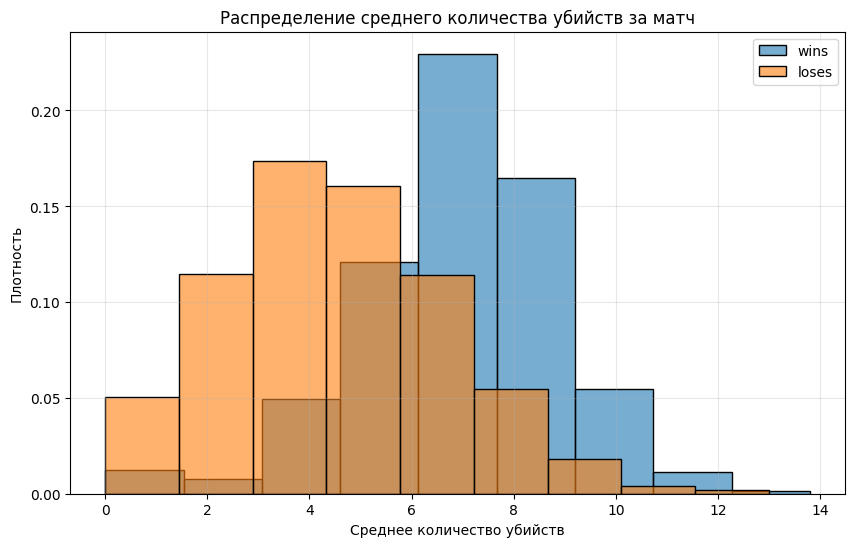

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df_win.kills, bins=9, stat='density', label='wins', alpha=0.6)
sns.histplot(df_los.kills, bins=9, stat='density', label='loses', alpha=0.6)

plt.title('Распределение среднего количества убийств за матч')
plt.xlabel('Среднее количество убийств')
plt.ylabel('Плотность')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

- При победах наблюдается широкий разброс: от 0 до 12+ убийств, но основная масса побед сосредоточена в интервале 6–9 убийств.
- При поражениях диапазон уже: большинство проигрышей приходится на 0–6 убийств, а значения выше 8 встречаются крайне редко.

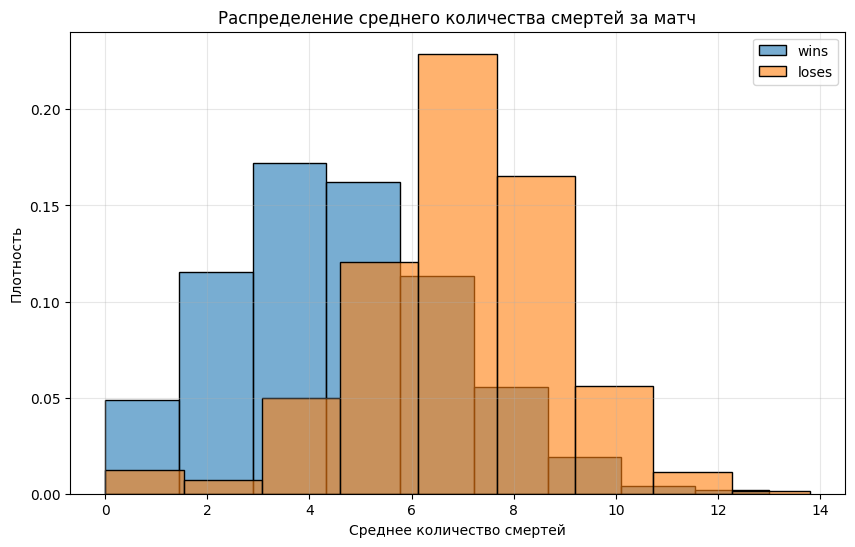

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df_win.deaths, bins=9, stat='density', label='wins', alpha=0.6)
sns.histplot(df_los.deaths, bins=9, stat='density', label='loses', alpha=0.6)

plt.title('Распределение среднего количества смертей за матч')
plt.xlabel('Среднее количество смертей')
plt.ylabel('Плотность')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

- При победах наблюдается более узкий и компактный диапазон: основная масса побед сосредоточена в интервале 0–5 смертей.
- При поражениях диапазон значительно шире: значительное количество проигрышей приходится на 6–12 смертей, а хвост распределения уходит далеко вправо.

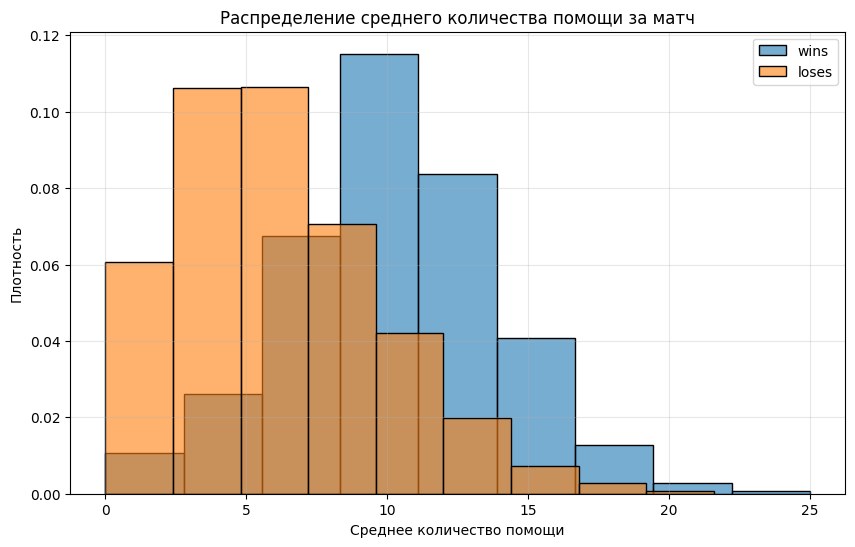

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df_win.assists, bins=9, stat='density', label='wins', alpha=0.6)
sns.histplot(df_los.assists, bins=9, stat='density', label='loses', alpha=0.6)

plt.title('Распределение среднего количества помощи за матч')
plt.xlabel('Среднее количество помощи')
plt.ylabel('Плотность')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

- При поражениях распределение компактное: основная масса проигрышей сосредоточена в интервале 0–8 помощи.
- При победах наблюдается более широкий и «тяжелый» вправо диапазон: значительная часть побед приходится на 10–15+ помощи, а хвост распределения уходит далеко за 20.

In [ ]:
query_df = '''
SELECT champion, win,
       avg(gold_earned) as gold_earned,
       avg(damage_to_champions) as damage_to_champions,
       avg(minions_killed) as minions_killed
FROM read_parquet('parquet_data/matches.parquet')
GROUP BY champion, win
'''

avg_champion = duckdb.query(query_df).to_df()

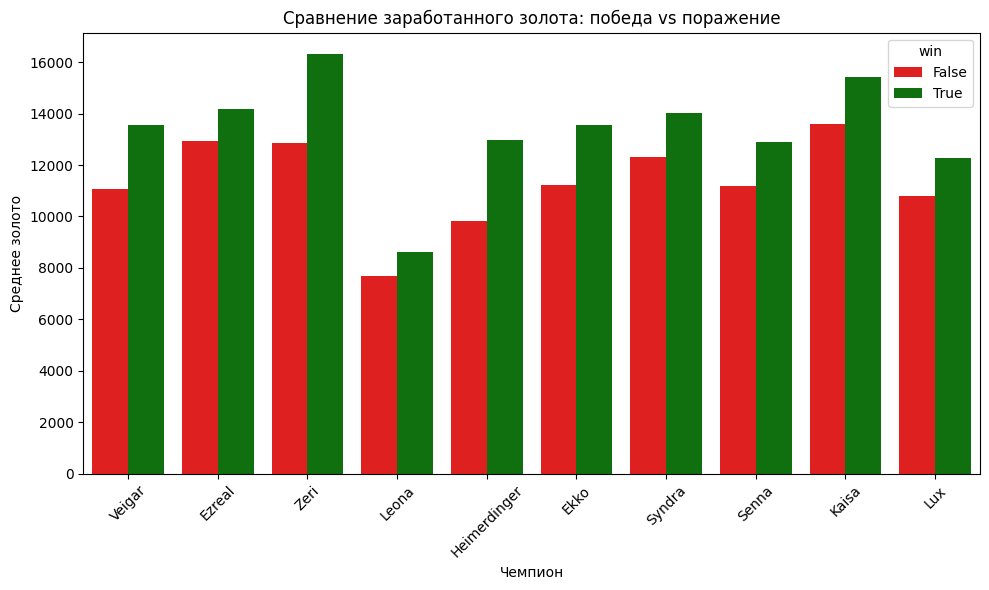

In [ ]:
# --- Выбераем топ-10 чемпионов по количеству игр ---
top_champs = avg_champion['champion'].value_counts().head(10).index
# Отфильтруем данные только для этих чемпионов
df_top = avg_champion[avg_champion['champion'].isin(top_champs)]
# Построим группированные столбцы: hue = win
plt.figure(figsize=(10, 6))

sns.barplot(data=df_top, x='champion', y='gold_earned', hue='win', 
            order=top_champs,  # фиксируем порядок
            palette={True: 'green', False: 'red'})  # зелёные – победы, красные – поражения

plt.title('Сравнение заработанного золота: победа vs поражение')
plt.xlabel('Чемпион')
plt.ylabel('Среднее золото')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Заработанное золото является надежным индикатором исхода матча. Чем больше золота удалось накопить к концу игры, тем выше вероятность победы. При этом разрыв в доходах между победой и поражением наиболее критичен для чемпионов, даже в проигранных матчах показатели остаются высокими, но всё же уступают победным.

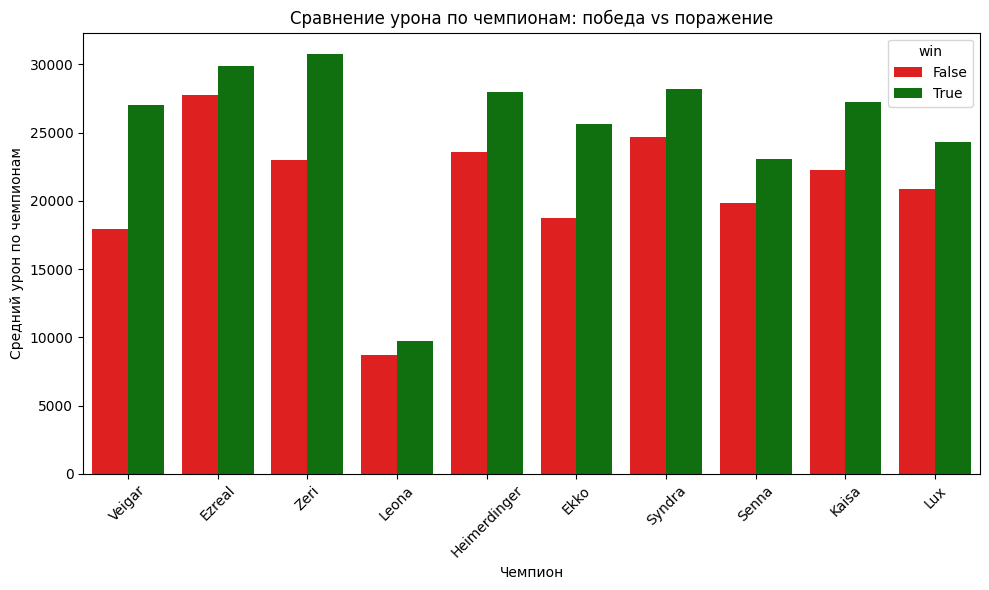

In [ ]:
# Построим группированные столбцы: hue = win
plt.figure(figsize=(10, 6))

sns.barplot(data=df_top, x='champion', y='damage_to_champions', hue='win', 
            order=top_champs,  # фиксируем порядок
            palette={True: 'green', False: 'red'})  # зелёные – победы, красные – поражения

plt.title('Сравнение урона по чемпионам: победа vs поражение')
plt.ylabel('Средний урон по чемпионам')
plt.xlabel('Чемпион')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Для большинства представленных чемпионов наблюдается устойчивая закономерность: в победных матчах средний урон стабильно выше, чем в проигранных. Зеленые столбцы почти всегда возвышаются над красными.При этом разрыв в показателях наиболее критичен для «дальнобойных» и «уронных», а для танков и лесников этот разрыв минимален, но тенденция сохраняется.

In [ ]:
data = pd.read_csv('players.csv')
# Задаём правильный порядок дивизионов (от низшего к высшему)
tier_order = ["MASTER", "GRANDMASTER", "CHALLENGER"]

# Преобразуем столбец в упорядоченный категориальный тип
data['range'] = pd.Categorical(data['range'], categories=tier_order, ordered=True)

# Получаем числовые коды
data['tier_code'] = data['range'].cat.codes

data_kmeans = data[['tier_code', 'league_points', 'winrate_%', 'matches_month']]
data_europe = data[data['region'] == 'europe'][['tier_code', 'league_points', 'winrate_%', 'matches_month']]
data_americas = data[data['region'] == 'americas'][['tier_code', 'league_points', 'winrate_%', 'matches_month']]

1. tier – после преобразования в порядковую шкалу. Это ключевой показатель мастерства.
2. league_points – очки внутри дивизиона, уточняют позицию внутри тира.
3. winrate_% – доля побед, отражает качество игры.
4. matches_month – количество игр за месяц, характеризует активность и опыт.

- Разделяющая способность: игроки с высоким тиром + высоким винрейтом + большим числом матчей образуют естественные кластеры (например, «активные профессионалы», «казуалы с высоким винрейтом», «начинающие с низким винрейтом» и т.д.).
- Интерпретируемость: полученные кластеры будут легко объяснимы через ранг, навык и вовлечённость.

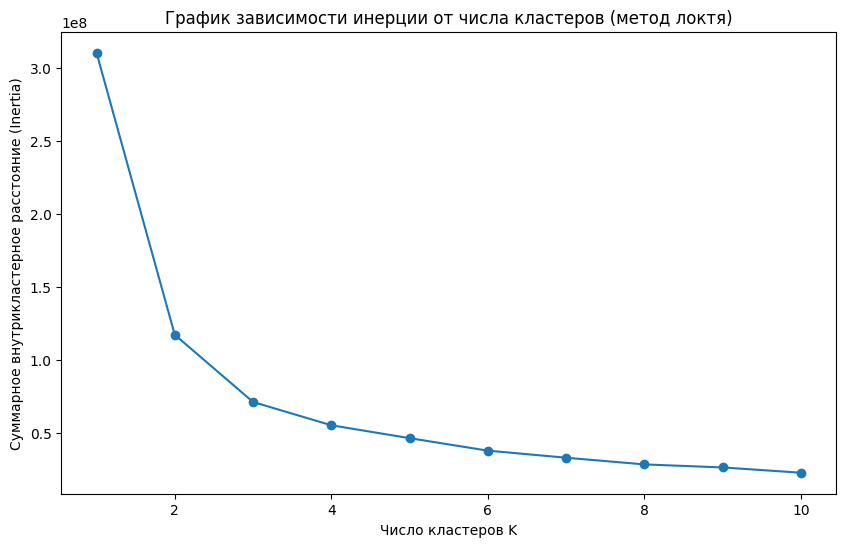

In [ ]:
# Создаём массив, в котором будем хранить значения inertia для разбиения с разным числом кластеров
i = []
# Задаём диапазон количества кластеров
min_k = 1
max_k = 10
# Перебираем разное количество кластеров
for k in range(min_k, max_k + 1):
   km = KMeans(n_clusters=k)  # Создаём модель KMeans для текущего значения k
   km.fit_transform(data_kmeans)  # Обучаем модель и получаем координаты точек в пространстве кластеров
   i.append(km.inertia_)  # Сохраняем значение инерции для текущего k

plt.figure(figsize=(10, 6))
# Строим график зависимости инерции от количества кластеров
plt.plot(range(min_k, max_k + 1), i, marker='o')

plt.xlabel('Число кластеров K')  # Подпись оси X
plt.ylabel('Суммарное внутрикластерное расстояние (Inertia)')  # Подпись оси Y
plt.title('График зависимости инерции от числа кластеров (метод локтя)')  # Заголовок

plt.show()


In [ ]:
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(data_kmeans)

# Сортируем кластеры по возрастанию «Продолжительности» (второй столбец, индекс 1)
sorted_indices = np.argsort(kmeans.cluster_centers_[:, 1])
sorted_centroids = kmeans.cluster_centers_[sorted_indices]

# Создаём DataFrame из центроидов
centroids_df = pd.DataFrame(
   sorted_centroids,
   columns=['Тир', 'Очки_лиги', 'Винрейт', 'Матчи'],
   index=[f'Кластер {i + 1}' for i in range(kmeans.n_clusters)]
)

# Форматируем числа для вывода (2 знака после точки)
pd.options.display.float_format = '{:.3f}'.format

# Выводим таблицу
print(centroids_df.head())

            Тир  Очки_лиги  Винрейт    Матчи
Кластер 1 0.040    386.416   50.347 1201.511
Кластер 2 0.464   1097.345   51.710 1136.417
Кластер 3 1.613   1994.462   53.232 1156.773


Кластер 1 – «Новички / Игроки низкого ранга»
- Самый низкий тир.
- Очки лиги заметно выше 100 — вероятно, это суммарные очки за всю историю или за несколько месяцев, а не текущие очки в дивизионе.
- Винрейт чуть выше 50% (близок к случайному).
- Наибольшее число матчей за месяц — много играют, но прогресса нет.

Характеристика: новички или «застрявшие» в самом низком ранге игроки с высокой активностью, но низкой эффективностью.

Кластер 2 – «Середина / Стабильные игроки»
- Тиp ближе к GRANDMASTER, но ещё не достиг его.
- Очки лиги уже выше 1000, что подтверждает интерпретацию «накопленных очков».
- Винрейт положительный (51.9%), активность чуть выше, чем в кластере 1.

Характеристика: игроки со средним навыком, постепенно поднимающиеся (или уже поднявшиеся до Bronze) с хорошей активностью и чуть положительным винрейтом.

Кластер 3 – «Лидеры / Наиболее сильные игроки»
- Самый высокий тир (в среднем выше GRANDMASTER).
- Максимальные накопленные очки лиги.
- Лучший винрейт (53.4%), активность выше, чем в кластере 1 и в кластере 2.

Характеристика: наиболее опытные и сильные игроки в выборке, демонстрирующие стабильно положительный винрейт и высокий ранг.

Общие выводы по кластеризации:
- Кластеризация хорошо разделила игроков по тиру и накопленным очкам лиги — эти признаки оказались самыми сильными.
- Винрейт различается незначительно (от 50.4% до 53.4%), но его вклад заметен при совместном учёте с рангом.
- Количество матчей за месяц почти одинаково во всех кластерах (~1100–1180), поэтому этот признак внёс меньший вклад в разделение.
- Итоговый набор признаков (tier_code, league_points, winrate_%, matches_month) показал себя работоспособным и позволил выделить осмысленные группы игроков — от новичков до лидеров.

In [ ]:
kmeans = KMeans(n_clusters=3)
labels_europe = kmeans.fit_predict(data_europe)

# Сортируем кластеры
sorted_indices = np.argsort(kmeans.cluster_centers_[:, 1])
sorted_centroids = kmeans.cluster_centers_[sorted_indices]

# Создаём DataFrame из центроидов
centroids_df = pd.DataFrame(
   sorted_centroids,
   columns=['Тир', 'Очки_лиги', 'Винрейт', 'Матчи'],
   index=[f'Кластер {i + 1}' for i in range(kmeans.n_clusters)]
)

# Форматируем числа для вывода (2 знака после точки)
pd.options.display.float_format = '{:.3f}'.format

# Выводим таблицу
print("=== Для Европы ===")
print(centroids_df.head())

kmeans = KMeans(n_clusters=3)
labels_americas = kmeans.fit_predict(data_americas)

# Сортируем кластеры
sorted_indices = np.argsort(kmeans.cluster_centers_[:, 1])
sorted_centroids = kmeans.cluster_centers_[sorted_indices]

# Создаём DataFrame из центроидов
centroids_df = pd.DataFrame(
   sorted_centroids,
   columns=['Тир', 'Очки_лиги', 'Винрейт', 'Матчи'],
   index=[f'Кластер {i + 1}' for i in range(kmeans.n_clusters)]
)

# Форматируем числа для вывода (2 знака после точки)
pd.options.display.float_format = '{:.3f}'.format

# Выводим таблицу
print("=== Для Америки ===")
print(centroids_df.head())

=== Для Европы ===
            Тир  Очки_лиги  Винрейт    Матчи
Кластер 1 0.018    506.728   50.519 1197.530
Кластер 2 0.362   1204.000   51.808 1143.628
Кластер 3 1.727   2074.303   53.404 1156.525
=== Для Америки ===
            Тир  Очки_лиги  Винрейт    Матчи
Кластер 1 0.010    181.462   50.048 1202.010
Кластер 2 0.508    683.186   50.933 1158.915
Кластер 3 1.800   1220.920   52.619 1097.360


Сравнение кластеров Европы и Америки
Кластер 1 («Новички / Застрявшие)
- Тир практически одинаковый.
- Очки лиги в Европе в 3.4 раза выше, чем в Америке — это самое резкое различие.
- Винрейт почти 50% в обоих регионах.
- Матчи в Америке чуть выше.

Вывод: игроки самого низкого уровня в Европе имеют гораздо больше накопленных очков лиги при схожем тире. Возможно, в Европе они дольше играют (наиграли больше очков), но не могут подняться. Или в Америке система очков работает иначе (например, меньше очков за победу).

Кластер 2 («Середина»)
- Тир в Европе немного выше.
- Очки лиги в Европе в 2 раза больше.
- Винрейт в Европе выше на 1.3%.
- Матчи почти одинаковы.

Вывод: игроки среднего уровня в Европе заметно сильнее (по тиру и винрейту) и имеют вдвое больше очков. В Америке этот кластер ближе к «новичкам», чем к «середнякам»

Кластер 3 («Лидеры»)
- Тир в Европе выше.
- Очки лиги в Европе почти в 2 раза больше.
- Винрейт в Европе чуть выше (+0.6%).
- Матчи в Европе немного выше.

Вывод: топ-игроки в Европе значительно сильнее и имеют намного больше очков. В Америке даже лучший кластер не дотягивает до европейского «середняка» по очкам.